# Coffee Vending Machine Sales: Exploratory Data Analysis

We have transaction-level data from two vending machines. This notebook
establishes why a **two-stage forecasting approach** (Poisson GLM on
total volume, then historical product-mix proportions) is the right fit
for this data, and what that means for stocking recommendations.


In [1]:
import os
from pathlib import Path

_mpl_dir = Path.cwd() / ".mplconfig"
_mpl_dir.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_mpl_dir))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

try:
    get_ipython()
    _IN_NOTEBOOK = True
except NameError:
    _IN_NOTEBOOK = False

if _IN_NOTEBOOK:
    if "vscode" in pio.renderers:
        pio.renderers.default = "vscode"
    elif "notebook_connected" in pio.renderers:
        pio.renderers.default = "notebook_connected"
    else:
        pio.renderers.default = "plotly_mimetype+notebook"
else:
    matplotlib.use("Agg")
    pio.renderers.default = "json"

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

WEEKDAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]


def map_hour_bucket(hour: int) -> str:
    if 6 <= hour < 9:
        return "06-09"
    if 9 <= hour < 12:
        return "09-12"
    if 12 <= hour < 15:
        return "12-15"
    if 15 <= hour < 18:
        return "15-18"
    if 18 <= hour < 21:
        return "18-21"
    return "outside"


In [2]:
repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
data_dir = repo_root / "data"

df1 = pd.read_csv(data_dir / "index_1.csv")
df2 = pd.read_csv(data_dir / "index_2.csv")

if "card" not in df2.columns:
    df2["card"] = pd.NA

df1["machine_id"] = "machine_1"
df2["machine_id"] = "machine_2"
df = pd.concat([df1, df2], ignore_index=True)

for col in ["date", "datetime"]:
    df[col] = pd.to_datetime(df[col], errors="coerce", format="mixed")

df["money"] = pd.to_numeric(df["money"], errors="coerce")
df["hour"] = df["datetime"].dt.hour
df["weekday"] = pd.Categorical(df["datetime"].dt.day_name(), categories=WEEKDAY_ORDER, ordered=True)
df["week_start"] = (df["datetime"] - pd.to_timedelta(df["datetime"].dt.weekday, unit="D")).dt.normalize()
df["sale_date"] = df["datetime"].dt.date
df["hour_bucket"] = df["hour"].map(map_hour_bucket)

print(f"{len(df):,} transactions loaded across {df['machine_id'].nunique()} machines")
display(df.head())


3,898 transactions loaded across 2 machines


,date,datetime,cash_type,card,money,coffee_name,machine_id,hour,weekday,week_start,sale_date,hour_bucket
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,machine_1,10,Friday,2024-02-26,2024-03-01,09-12
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,machine_1,12,Friday,2024-02-26,2024-03-01,12-15
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,machine_1,12,Friday,2024-02-26,2024-03-01,12-15
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,machine_1,13,Friday,2024-02-26,2024-03-01,12-15
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,machine_1,13,Friday,2024-02-26,2024-03-01,12-15


## How different are the two machines?

Machine 1 has roughly a year of dense data; Machine 2 has about six weeks. This
volume gap matters for every modeling decision that follows.


In [3]:
daily_txn = (
    df.groupby(["machine_id", "sale_date"], as_index=False)
    .size()
    .rename(columns={"size": "transactions"})
)

rows = []
for mid, grp in df.groupby("machine_id", sort=True):
    per_day = daily_txn.loc[daily_txn["machine_id"].eq(mid), "transactions"]
    rows.append({
        "machine_id": mid,
        "total_transactions": len(grp),
        "date_range": f"{grp['date'].min().date()} to {grp['date'].max().date()}",
        "unique_products": grp["coffee_name"].nunique(),
        "avg_transactions_per_day": round(per_day.mean(), 1),
        "median_transactions_per_day": per_day.median(),
    })

display(pd.DataFrame(rows))

fig = px.bar(
    pd.DataFrame(rows),
    x="machine_id",
    y="total_transactions",
    title="Total Transactions by Machine",
    labels={"machine_id": "Machine", "total_transactions": "Number of Transactions"},
    text_auto=True,
)
fig.update_layout(showlegend=False)
fig.show()


,machine_id,total_transactions,date_range,unique_products,avg_transactions_per_day,median_transactions_per_day
0,machine_1,3636,2024-03-01 to 2025-03-23,8,9.5,9.0
1,machine_2,262,2025-02-08 to 2025-03-23,30,6.4,5.0


## When do customers buy?

These patterns (hour of day, day of week) are the main features our model will use.
If weekly volume is roughly flat over time, we do not need a trend or seasonality term.


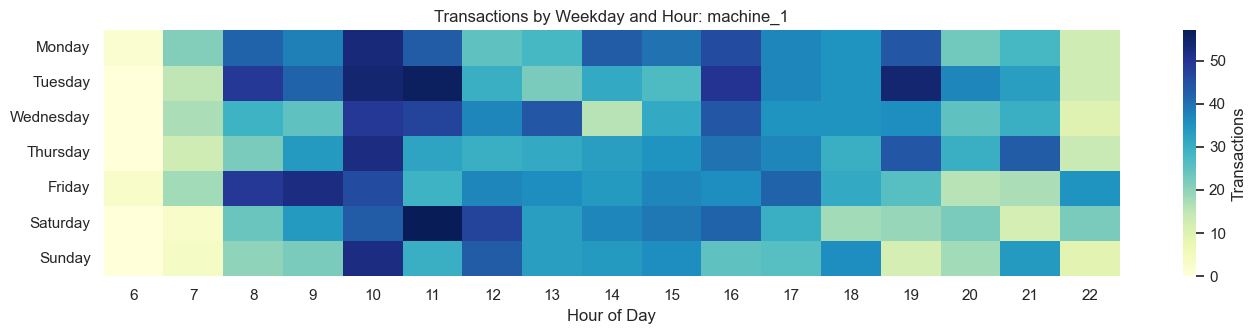

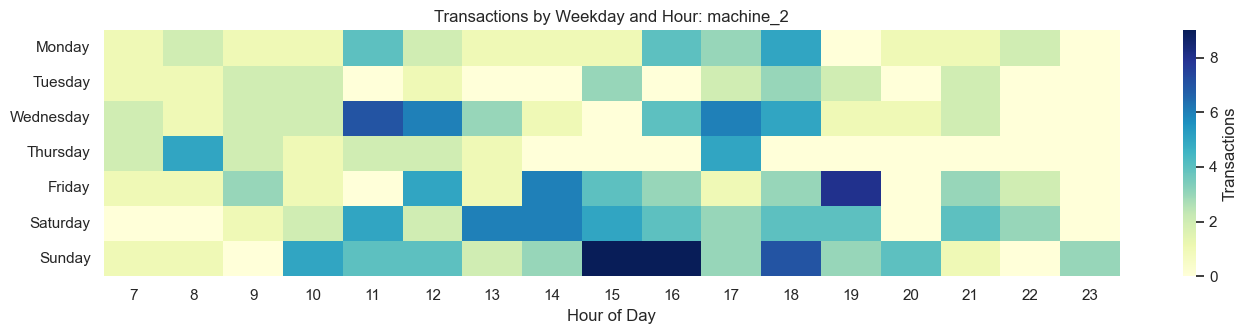

In [4]:
hourly = (
    df.groupby(["machine_id", "hour"], as_index=False)
    .size()
    .rename(columns={"size": "transactions"})
)

fig = px.bar(
    hourly,
    x="hour",
    y="transactions",
    color="machine_id",
    barmode="group",
    title="Transactions by Hour of Day",
    labels={"hour": "Hour of Day", "transactions": "Number of Transactions", "machine_id": "Machine"},
)
fig.update_xaxes(dtick=1)
fig.show()

for machine in sorted(df["machine_id"].dropna().unique()):
    pivot = (
        df.loc[df["machine_id"].eq(machine)]
        .groupby(["weekday", "hour"], observed=False)
        .size()
        .reset_index(name="transactions")
        .pivot(index="weekday", columns="hour", values="transactions")
        .reindex(index=WEEKDAY_ORDER)
        .fillna(0)
    )
    plt.figure(figsize=(14, 3.5))
    sns.heatmap(pivot, cmap="YlGnBu", cbar_kws={"label": "Transactions"})
    plt.title(f"Transactions by Weekday and Hour: {machine}")
    plt.xlabel("Hour of Day")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

weekly = (
    df.groupby(["machine_id", "week_start"], as_index=False)
    .size()
    .rename(columns={"size": "transactions"})
    .sort_values(["machine_id", "week_start"])
)

fig = px.line(
    weekly,
    x="week_start",
    y="transactions",
    color="machine_id",
    markers=True,
    title="Weekly Transaction Volume Over Time",
    labels={"week_start": "Week Starting", "transactions": "Transactions per Week", "machine_id": "Machine"},
)
fig.show()


### Product and payment breakdown

A quick look at the product mix and payment method. We will build the full
product-mix analysis later; here we just confirm the basic distribution.


In [5]:
display(df.groupby("machine_id")["coffee_name"].value_counts().rename("transactions").reset_index())

cash_pct = df["cash_type"].value_counts(normalize=True).mul(100).round(1)
print(f"Payment split: {cash_pct.to_dict()}")


,machine_id,coffee_name,transactions
0,machine_1,Americano with Milk,824
1,machine_1,Latte,782
2,machine_1,Americano,578
3,machine_1,Cappuccino,501
4,machine_1,Cortado,292
5,machine_1,Hot Chocolate,282
6,machine_1,Cocoa,243
7,machine_1,Espresso,134
8,machine_2,Americano with milk,44
9,machine_2,Latte,24


Payment split: {'card': 95.7, 'cash': 4.3}


## Can we model demand per product?

The natural modeling target would be per-product demand in each 3-hour window:
"how many Lattes will Machine 1 sell between 9am and noon on a Monday?" To see
if this is viable, we aggregate to `(date, hour_bucket, product, machine)` counts
and check how sparse the resulting matrix is.


In [6]:
bucket_counts = (
    df.groupby(["sale_date", "hour_bucket", "coffee_name", "machine_id"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

count_dist = bucket_counts["count"].value_counts().sort_index()
print("Distribution of non-zero cell counts:")
display(pd.DataFrame({"drinks_sold": count_dist.index.astype(int), "number_of_cells": count_dist.values}))
print(f"\nTotal non-zero cells: {len(bucket_counts):,}")

# Build the full grid (every possible date x bucket x product x machine combination)
# using each machine's own product list so we don't count impossible SKU/machine pairs.
grid_parts = []
all_dates = sorted(df["sale_date"].dropna().unique())
all_buckets = sorted(df["hour_bucket"].dropna().unique())

for mid in sorted(df["machine_id"].dropna().unique()):
    prods = sorted(df.loc[df["machine_id"].eq(mid), "coffee_name"].dropna().unique())
    g = pd.MultiIndex.from_product(
        [all_dates, all_buckets, prods, [mid]],
        names=["sale_date", "hour_bucket", "coffee_name", "machine_id"],
    ).to_frame(index=False)
    grid_parts.append(g)

full_grid = pd.concat(grid_parts, ignore_index=True)
bucket_counts_full = full_grid.merge(bucket_counts, how="left")
bucket_counts_full["count"] = bucket_counts_full["count"].fillna(0).astype(int)

zero_rate = (
    bucket_counts_full.groupby("machine_id", as_index=False)
    .agg(
        total_cells=("count", "size"),
        zero_cells=("count", lambda s: int((s == 0).sum())),
    )
)
zero_rate["zero_rate"] = (zero_rate["zero_cells"] / zero_rate["total_cells"]).round(4)
display(zero_rate)


Distribution of non-zero cell counts:


,drinks_sold,number_of_cells
0,1,2268
1,2,542
2,3,126
3,4,31
4,5,5
5,6,2
6,7,1



Total non-zero cells: 2,975


,machine_id,total_cells,zero_cells,zero_rate
0,machine_1,18288,15553,0.8504
1,machine_2,68580,68340,0.9965


The vast majority of product-level cells are zero. Most non-zero cells contain
exactly 1 sale. Asking a model to distinguish between 0 and 1 at this granularity
is not useful for stocking decisions.

Next we check dispersion (variance / mean) at the product level. For a Poisson
model to be appropriate, dispersion should be close to 1.0.


In [7]:
stats_product = (
    bucket_counts
    .groupby(["machine_id", "hour_bucket", "coffee_name"], as_index=False)
    .agg(mean=("count", "mean"), variance=("count", "var"), n_days=("count", "size"))
    .fillna({"variance": 0.0})
)
stats_product["dispersion"] = np.where(
    stats_product["mean"] > 0,
    stats_product["variance"] / stats_product["mean"],
    np.nan,
)

disp_summary = stats_product.groupby("machine_id", as_index=False).agg(
    median_dispersion=("dispersion", "median"),
    mean_dispersion=("dispersion", "mean"),
)
print("Dispersion at the per-product level:")
display(disp_summary)

fig = px.scatter(
    stats_product,
    x="mean",
    y="variance",
    color="machine_id",
    hover_data=["hour_bucket", "coffee_name", "dispersion"],
    title="Per-Product Dispersion: Variance vs. Mean",
    labels={
        "mean": "Mean Drinks per 3-Hour Window",
        "variance": "Variance of Drinks per 3-Hour Window",
        "machine_id": "Machine",
    },
)
mx = float(stats_product["mean"].max() or 1)
fig.add_shape(type="line", x0=0, y0=0, x1=mx, y1=mx, line=dict(dash="dash"), name="Var = Mean")
fig.add_annotation(x=mx * 0.85, y=mx * 0.85, text="Variance = Mean", showarrow=False, font=dict(size=11))
fig.show()


Dispersion at the per-product level:


,machine_id,median_dispersion,mean_dispersion
0,machine_1,0.25325,0.251263
1,machine_2,0.00000,0.037843


## What happens when we aggregate to total volume?

Instead of predicting per-product counts, we collapse products and predict **total
drinks sold** per 3-hour window per machine. This gives us counts in the 1-14 range
instead of 0-1, and dispersion should move toward 1.0 (the Poisson sweet spot).


In [8]:
volume = (
    df.groupby(["sale_date", "hour_bucket", "machine_id"], as_index=False)
    .size()
    .rename(columns={"size": "total_drinks"})
)

fig = px.histogram(
    volume,
    x="total_drinks",
    facet_col="machine_id",
    title="Distribution of Total Drinks Sold per 3-Hour Window",
    labels={"total_drinks": "Total Drinks Sold", "count": "Number of Windows"},
    opacity=0.85,
)
fig.update_layout(bargap=0.08)
fig.for_each_yaxis(lambda ax: ax.update(title_text="Number of Windows"))
fig.show()

stats_volume = (
    volume.groupby(["machine_id", "hour_bucket"], as_index=False)
    .agg(mean=("total_drinks", "mean"), variance=("total_drinks", "var"), n_days=("total_drinks", "size"))
    .fillna({"variance": 0.0})
)
stats_volume["dispersion"] = np.where(
    stats_volume["mean"] > 0,
    stats_volume["variance"] / stats_volume["mean"],
    np.nan,
)

print("Dispersion at the total-volume level (by machine and 3-hour window):")
display(stats_volume.sort_values(["machine_id", "hour_bucket"]))

fig2 = px.scatter(
    stats_volume,
    x="mean",
    y="variance",
    color="machine_id",
    hover_data=["hour_bucket", "n_days", "dispersion"],
    title="Volume-Level Dispersion: Variance vs. Mean",
    labels={
        "mean": "Mean Drinks per 3-Hour Window",
        "variance": "Variance of Drinks per 3-Hour Window",
        "machine_id": "Machine",
    },
)
mx2 = float(stats_volume["mean"].max() or 1)
fig2.add_shape(type="line", x0=0, y0=0, x1=mx2, y1=mx2, line=dict(dash="dash"))
fig2.add_annotation(x=mx2 * 0.85, y=mx2 * 0.85, text="Variance = Mean", showarrow=False, font=dict(size=11))
fig2.show()


Dispersion at the total-volume level (by machine and 3-hour window):


,machine_id,hour_bucket,mean,variance,n_days,dispersion
0,machine_1,06-09,1.924419,1.403611,172,0.729369
1,machine_1,09-12,2.772586,3.401246,321,1.226742
2,machine_1,12-15,2.588235,2.767094,272,1.069104
3,machine_1,15-18,2.848708,4.039989,271,1.418183
4,machine_1,18-21,2.555102,2.321746,245,0.908671
5,machine_1,outside,2.204225,1.511188,142,0.685587
6,machine_2,06-09,1.461538,0.602564,13,0.412281
7,machine_2,09-12,1.958333,2.389493,24,1.220167
8,machine_2,12-15,2.523810,1.861905,21,0.737736
9,machine_2,15-18,2.300000,1.734483,30,0.754123


Dispersion ratios at the volume level cluster much closer to 1.0. A Poisson GLM
is well-suited here: the model learns "how busy is this machine at this time?"
and we split the total forecast into per-product recommendations using historical
proportions (Stage 2).


## Is the product mix stable enough for historical proportions?

Stage 2 of the model uses simple historical frequencies ("35% of morning sales at
Machine 1 are Lattes") to split the volume forecast into per-product stocking numbers.
This only works if the product mix is reasonably stable over time.

We split each machine's data into a first half and second half by date, compute
product proportions per 3-hour window, and compare.


In [9]:
def mix_half_comparison(frame: pd.DataFrame, machine_id: str) -> pd.DataFrame:
    sub = frame.loc[frame["machine_id"].eq(machine_id)].copy()
    dates = sorted(sub["sale_date"].dropna().unique())
    first_dates = set(dates[: len(dates) // 2])
    second_dates = set(dates[len(dates) // 2 :])
    h1, h2 = sub.loc[sub["sale_date"].isin(first_dates)], sub.loc[sub["sale_date"].isin(second_dates)]

    def proportions(part):
        counts = part.groupby(["hour_bucket", "coffee_name"], observed=False).size().rename("n").reset_index()
        totals = part.groupby("hour_bucket", observed=False).size().rename("total").reset_index()
        merged = counts.merge(totals, on="hour_bucket")
        merged["proportion"] = merged["n"] / merged["total"]
        return merged

    p1 = proportions(h1).rename(columns={"proportion": "first_half", "n": "n_first", "total": "total_first"})
    p2 = proportions(h2).rename(columns={"proportion": "second_half", "n": "n_second", "total": "total_second"})
    cmp = p1.merge(p2[["hour_bucket", "coffee_name", "second_half"]], on=["hour_bucket", "coffee_name"], how="outer")
    cmp["first_half"] = cmp["first_half"].fillna(0.0)
    cmp["second_half"] = cmp["second_half"].fillna(0.0)
    cmp["abs_diff"] = (cmp["second_half"] - cmp["first_half"]).abs()
    return cmp.sort_values("abs_diff", ascending=False)


print("Machine 1: product mix, first half vs. second half (sorted by largest shift)")
mix_m1 = mix_half_comparison(df, "machine_1")
display(mix_m1.head(20))


Machine 1: product mix, first half vs. second half (sorted by largest shift)


,hour_bucket,coffee_name,n_first,total_first,first_half,second_half,abs_diff
46,outside,Hot Chocolate,8,137,0.058394,0.227273,0.168879
35,18-21,Cocoa,16,287,0.055749,0.147493,0.091743
15,09-12,Latte,92,410,0.224390,0.135417,0.088974
4,06-09,Cortado,21,112,0.187500,0.100457,0.087043
42,outside,Cappuccino,24,137,0.175182,0.090909,0.084273
41,outside,Americano with Milk,41,137,0.299270,0.215909,0.083361
17,12-15,Americano with Milk,79,299,0.264214,0.192593,0.071621
34,18-21,Cappuccino,69,287,0.240418,0.176991,0.063427
30,15-18,Hot Chocolate,17,274,0.062044,0.122490,0.060446
3,06-09,Cocoa,2,112,0.017857,0.077626,0.059768


Machine 1's top products shift by less than ~9 percentage points between halves.
The mix is stable enough to use historical frequencies for Stage 2.

Machine 2 tells a different story:


In [10]:
print("Machine 2: product mix, first half vs. second half (sorted by largest shift)")
mix_m2 = mix_half_comparison(df, "machine_2")
display(mix_m2.head(20))


Machine 2: product mix, first half vs. second half (sorted by largest shift)


,hour_bucket,coffee_name,n_first,total_first,first_half,second_half,abs_diff
19,09-12,Irish whiskey,2.0,25.0,0.080000,0.318182,0.238182
88,outside,Coffee with Irish whiskey,2.0,6.0,0.333333,0.117647,0.215686
44,12-15,Tea,6.0,23.0,0.260870,0.066667,0.194203
91,outside,Irish whiskey with milk,NaN,NaN,0.000000,0.176471,0.176471
85,outside,Caramel coffee,1.0,6.0,0.166667,0.000000,0.166667
0,06-09,Americano,1.0,11.0,0.090909,0.250000,0.159091
3,06-09,Coffee with Irish whiskey,1.0,11.0,0.090909,0.250000,0.159091
2,06-09,Cappuccino,3.0,11.0,0.272727,0.125000,0.147727
72,18-21,Coffee with Irish whiskey,5.0,27.0,0.185185,0.041667,0.143519
59,15-18,Irish whiskey,1.0,37.0,0.027027,0.156250,0.129223


With only ~250 transactions, Machine 2's mix is erratic: products appear and
disappear between time periods. We cannot rely on Machine 2's own product
proportions, so we fall back to Machine 1's mix for both machines (flagged clearly
in the UI so the manager knows).

### Which products are too rare to recommend?

When the 90th-percentile volume forecast for a window is ~5 total drinks, a product
at 3% of the mix yields an expected demand of 0.15. That rounds to zero and is not
actionable. Products below ~5% of a given window go into a "rarely ordered" footnote
instead of the main recommendation.


In [11]:
m1 = df.loc[df["machine_id"].eq("machine_1")]
totals = m1.groupby("hour_bucket", observed=False).size().rename("window_total").reset_index()
shares = (
    m1.groupby(["hour_bucket", "coffee_name"], observed=False)
    .size()
    .rename("transactions")
    .reset_index()
    .merge(totals, on="hour_bucket")
)
shares["share"] = shares["transactions"] / shares["window_total"]
shares["below_5pct"] = shares["share"] < 0.05
shares = shares.sort_values(["hour_bucket", "share"], ascending=[True, False])

print("Machine 1: product share by 3-hour window")
display(shares)

rare = shares.loc[shares["below_5pct"], ["hour_bucket", "coffee_name", "share"]]
print(f"\n{len(rare)} product/window combinations fall below 5% (footnote, not main rec):")
display(rare)


Machine 1: product share by 3-hour window


,hour_bucket,coffee_name,transactions,window_total,share,below_5pct
7,06-09,Latte,77,331,0.232628,False
1,06-09,Americano with Milk,72,331,0.217523,False
0,06-09,Americano,64,331,0.193353,False
2,06-09,Cappuccino,43,331,0.129909,False
4,06-09,Cortado,43,331,0.129909,False
3,06-09,Cocoa,19,331,0.057402,False
5,06-09,Espresso,8,331,0.024169,True
6,06-09,Hot Chocolate,5,331,0.015106,True
9,09-12,Americano with Milk,264,890,0.296629,False
8,09-12,Americano,161,890,0.180899,False



10 product/window combinations fall below 5% (footnote, not main rec):


,hour_bucket,coffee_name,share
5,06-09,Espresso,0.024169
6,06-09,Hot Chocolate,0.015106
11,09-12,Cocoa,0.044944
13,09-12,Espresso,0.042697
21,12-15,Espresso,0.045455
22,12-15,Hot Chocolate,0.045455
29,15-18,Espresso,0.046632
36,18-21,Cortado,0.044728
37,18-21,Espresso,0.025559
45,outside,Espresso,0.012780


## Model V1: Poisson GLM with Day-of-Week

Our first model uses `day_of_week + hour_bucket + machine_id` as features —
the time-of-day pattern, which day it is, and which machine. We compare it
against two naive baselines on the **same Machine 1 test set** (post-cutoff):

1. **Global Average** — training-set mean for each `(hour_bucket, machine)` pair, every day.
2. **Yesterday's Actual** — whatever actually sold in the same slot the previous calendar day.

In [12]:
import sys
import statsmodels.api as _sm
from scipy.stats import poisson as _poisson

sys.path.insert(0, str(repo_root))
from models.forecaster import TRAIN_FRACTION

# Re-use `volume` from earlier cell, align column names with modeling code
vol = volume.copy()
vol["sale_date"] = pd.to_datetime(vol["sale_date"] if vol["sale_date"].dtype == "object" else vol["sale_date"])
vol = vol.rename(columns={"total_drinks": "total_count"})
vol["day_of_week"] = vol["sale_date"].dt.dayofweek

# Time-based train/test split (same logic as DemandForecaster)
m1_dates = sorted(vol.loc[vol["machine_id"] == "machine_1", "sale_date"].unique())
cutoff_date = m1_dates[int(len(m1_dates) * TRAIN_FRACTION)]

is_m1 = vol["machine_id"] == "machine_1"
train_mask = (~is_m1) | (vol["sale_date"] < cutoff_date)
test_mask = is_m1 & (vol["sale_date"] >= cutoff_date)

train = vol.loc[train_mask]
test_m1 = vol.loc[test_mask].copy()
train_m1 = vol.loc[is_m1 & (vol["sale_date"] < cutoff_date)]
actual = test_m1["total_count"].values

# ── V1: Poisson GLM with day_of_week ──────────────────────────────
X_train_v1 = pd.get_dummies(
    train[["day_of_week", "hour_bucket", "machine_id"]],
    columns=["day_of_week", "hour_bucket", "machine_id"],
    drop_first=True, dtype=float,
)
X_train_v1 = _sm.add_constant(X_train_v1)
v1_result = _sm.GLM(train["total_count"], X_train_v1, family=_sm.families.Poisson()).fit()

X_test_v1 = pd.get_dummies(
    test_m1[["day_of_week", "hour_bucket", "machine_id"]],
    columns=["day_of_week", "hour_bucket", "machine_id"],
    drop_first=True, dtype=float,
)
X_test_v1 = _sm.add_constant(X_test_v1)
for c in X_train_v1.columns:
    if c not in X_test_v1.columns:
        X_test_v1[c] = 0.0
X_test_v1 = X_test_v1[X_train_v1.columns]

v1_mu = v1_result.predict(X_test_v1).values
v1_mae = round(float(np.mean(np.abs(actual - v1_mu))), 3)
v1_lo, v1_hi = _poisson.ppf(0.05, v1_mu), _poisson.ppf(0.95, v1_mu)
v1_cov = round(float(((actual >= v1_lo) & (actual <= v1_hi)).mean()), 3)

# ── Baselines ─────────────────────────────────────────────────────
ga_means = (
    train_m1.groupby(["hour_bucket", "machine_id"], as_index=False)["total_count"]
    .mean().rename(columns={"total_count": "ga_pred"})
)
ga_mu = test_m1.merge(ga_means, on=["hour_bucket", "machine_id"], how="left")["ga_pred"].fillna(0).values
ga_mae = round(float(np.mean(np.abs(actual - ga_mu))), 3)
ga_cov = round(float(((actual >= _poisson.ppf(0.05, ga_mu)) & (actual <= _poisson.ppf(0.95, ga_mu))).mean()), 3)

yd_lookup = vol.loc[is_m1].set_index(["sale_date", "hour_bucket"])["total_count"].to_dict()
yd_preds = np.array([
    yd_lookup.get((r["sale_date"] - pd.Timedelta(days=1), r["hour_bucket"]), 0)
    for _, r in test_m1.iterrows()
], dtype=float)
yd_mae = round(float(np.mean(np.abs(actual - yd_preds))), 3)
yd_mu_safe = np.maximum(yd_preds, 0.0)
yd_cov = round(float(((actual >= _poisson.ppf(0.05, yd_mu_safe)) & (actual <= _poisson.ppf(0.95, yd_mu_safe))).mean()), 3)

# ── Comparison table ──────────────────────────────────────────────
comparison_v1 = pd.DataFrame([
    {"Strategy": "V1: Poisson GLM (with DOW)", "MAE": v1_mae, "90% Coverage": f"{v1_cov:.1%}"},
    {"Strategy": "Global Average", "MAE": ga_mae, "90% Coverage": f"{ga_cov:.1%}"},
    {"Strategy": "Yesterday's Actual", "MAE": yd_mae, "90% Coverage": f"{yd_cov:.1%}"},
])

print(f"Test set: {len(test_m1)} slots  |  Cutoff date: {cutoff_date.date()}\n")
display(comparison_v1.style.hide(axis="index"))

Test set: 316 slots  |  Cutoff date: 2025-01-04



Strategy,MAE,90% Coverage
V1: Poisson GLM (with DOW),1.521000,89.2%
Global Average,1.514000,89.9%
Yesterday's Actual,1.949000,69.6%


In [13]:
WEEKDAY_NAMES = ["Monday", "Tuesday", "Wednesday", "Thursday",
                 "Friday", "Saturday", "Sunday"]

rows = []
for name in v1_result.params.index:
    if name == "const":
        continue
    label = name
    if name.startswith("day_of_week_"):
        label = f"DOW: {WEEKDAY_NAMES[int(name.split('_')[-1])]}"
    elif name.startswith("hour_bucket_"):
        label = name.replace("hour_bucket_", "Hour ")
    elif name.startswith("machine_id_"):
        label = name.replace("machine_id_", "").replace("_", " ").title()
    rows.append({
        "Feature": label,
        "exp(coef)": round(np.exp(v1_result.params[name]), 3),
        "p-value": round(float(v1_result.pvalues[name]), 4),
        "Sig.": "***" if v1_result.pvalues[name] < 0.001
                else "**" if v1_result.pvalues[name] < 0.01
                else "*" if v1_result.pvalues[name] < 0.05 else "",
    })

coef_df = pd.DataFrame(rows)
print("V1 coefficient table — exp(coef) is the demand multiplier vs. baseline\n")
display(coef_df.style.hide(axis="index"))

n_dow = sum(1 for n in v1_result.params.index if n.startswith("day_of_week_"))
n_sig = sum(1 for n in v1_result.params.index
            if n.startswith("day_of_week_") and v1_result.pvalues[n] < 0.05)
print(f"\nDay-of-week: {n_sig} of {n_dow} coefficients reach p < 0.05.")
print("The model is spending 6 parameters on effects indistinguishable from noise.")

V1 coefficient table — exp(coef) is the demand multiplier vs. baseline



Feature,exp(coef),p-value,Sig.
DOW: Tuesday,1.127000,0.074100,
DOW: Wednesday,1.003000,0.968900,
DOW: Thursday,0.988000,0.863500,
DOW: Friday,1.015000,0.828800,
DOW: Saturday,1.075000,0.292200,
DOW: Sunday,1.015000,0.827500,
Hour 09-12,1.417000,0.000000,***
Hour 12-15,1.372000,0.000000,***
Hour 15-18,1.322000,0.000200,***
Hour 18-21,1.330000,0.000200,***



Day-of-week: 0 of 6 coefficients reach p < 0.05.
The model is spending 6 parameters on effects indistinguishable from noise.


In [14]:
test_m1["pred_v1"] = v1_mu
test_m1["pred_ga"] = ga_mu
test_m1["pred_yd"] = yd_preds

for tag in ["v1", "ga", "yd"]:
    test_m1[f"ae_{tag}"] = np.abs(test_m1["total_count"] - test_m1[f"pred_{tag}"])

test_m1["dow_name"] = test_m1["sale_date"].dt.day_name()

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_mae = (
    test_m1.groupby("dow_name")[["ae_v1", "ae_ga", "ae_yd"]]
    .mean().reindex(dow_order).round(2)
    .rename(columns={"ae_v1": "V1 (DOW GLM)", "ae_ga": "Global Average", "ae_yd": "Yesterday"})
)
dow_mae.index.name = "Day of Week"

print("MAE by Day of Week — no day consistently favors V1 over the Global Average\n")
display(dow_mae)

MAE by Day of Week — no day consistently favors V1 over the Global Average



,V1 (DOW GLM),Global Average,Yesterday
Day of Week,,,
Monday,1.91,1.89,2.65
Tuesday,1.25,1.24,1.86
Wednesday,1.85,1.86,1.59
Thursday,1.32,1.30,1.81
Friday,1.81,1.82,1.86
Saturday,1.26,1.25,2.21
Sunday,1.00,1.02,1.58


## Checking for Time Trends

Day-of-week adds nothing. But there is another dimension we haven't tested:
**is demand changing over time?** The global average weights March 2024 the same
as January 2025. If demand is growing (or shrinking), that flat average is biased.

Linear trend: +41 transactions/year (≈ 63% annual growth relative to mean)


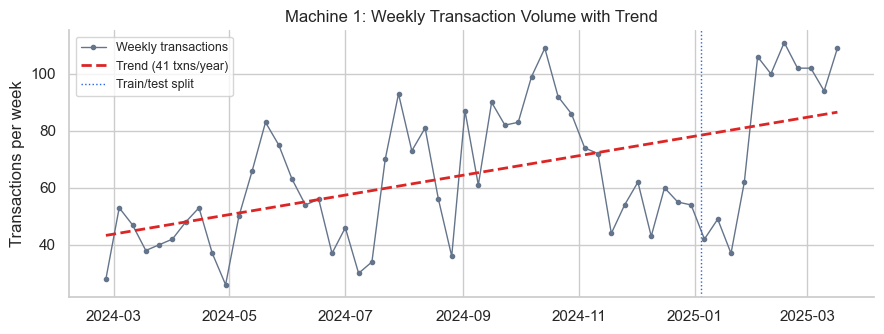

In [15]:
%matplotlib inline

weekly = (
    df.loc[df["machine_id"] == "machine_1"]
    .groupby("week_start", as_index=False)
    .size()
    .rename(columns={"size": "transactions"})
)
weekly["week_start"] = pd.to_datetime(weekly["week_start"])

x_num = (weekly["week_start"] - weekly["week_start"].min()).dt.days.values.astype(float)
slope, intercept = np.polyfit(x_num, weekly["transactions"].values, 1)
trend_line = intercept + slope * x_num

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(weekly["week_start"], weekly["transactions"], marker="o", markersize=3,
        linewidth=1, color="#64748b", label="Weekly transactions")
ax.plot(weekly["week_start"], trend_line, "--", color="#dc2626", linewidth=2,
        label=f"Trend ({slope * 365:.0f} txns/year)")
ax.axvline(cutoff_date, color="#2563eb", linewidth=1, linestyle=":", label="Train/test split")
ax.set_ylabel("Transactions per week")
ax.set_title("Machine 1: Weekly Transaction Volume with Trend")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

pct_growth = (slope * 365) / weekly["transactions"].mean() * 100
print(f"Linear trend: +{slope * 365:.0f} transactions/year "
      f"(≈ {pct_growth:.0f}% annual growth relative to mean)")

## Model V2: Drop Day-of-Week, Add Time Trend

The evidence is clear: day-of-week is noise, but there is a real growth trend.
Our refined model uses `hour_bucket + machine_id + trend` — replacing six
insignificant DOW dummies with a single significant trend term.

Test set: 316 slots  |  Cutoff: 2025-01-04  |  Dispersion: 0.827



Strategy,MAE,90% Coverage
"V2: GLM (trend, no DOW)",1.498000,93.4%
"V1: GLM (DOW, no trend)",1.521000,89.2%
Global Average,1.514000,89.9%
Yesterday's Actual,1.949000,69.6%



Trend coefficient: exp(0.2021) = 1.22x per year  (p = 0.0140)


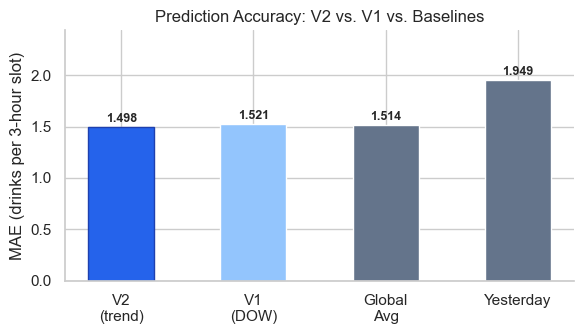

In [16]:
%matplotlib inline
import importlib, models.forecaster as _mf
importlib.reload(_mf)
from models.forecaster import DemandForecaster

fc = DemandForecaster(data_dir=repo_root / "data")

v2 = fc.eval_metrics
bm = fc.baseline_metrics
trend_coef = fc._fit_result.params.get("trend", 0.0)
trend_pval = fc._fit_result.pvalues.get("trend", 1.0)

comparison_all = pd.DataFrame([
    {
        "Strategy": "V2: GLM (trend, no DOW)",
        "MAE": v2["mae"],
        "90% Coverage": f"{v2['interval_coverage_90']:.1%}",
    },
    {
        "Strategy": "V1: GLM (DOW, no trend)",
        "MAE": v1_mae,
        "90% Coverage": f"{v1_cov:.1%}",
    },
    {
        "Strategy": "Global Average",
        "MAE": bm["global_average"]["mae"],
        "90% Coverage": f"{bm['global_average']['interval_coverage_90']:.1%}",
    },
    {
        "Strategy": "Yesterday's Actual",
        "MAE": bm["yesterday"]["mae"],
        "90% Coverage": f"{bm['yesterday']['interval_coverage_90']:.1%}",
    },
])

print(f"Test set: {v2['n_test']} slots  |  Cutoff: {v2['cutoff_date']}  |  "
      f"Dispersion: {v2['dispersion']}\n")
display(comparison_all.style.hide(axis="index"))

print(f"\nTrend coefficient: exp({trend_coef:.4f}) = {np.exp(trend_coef):.2f}x per year  "
      f"(p = {trend_pval:.4f})")

# ── Bar chart ─────────────────────────────────────────────────────
mae_vals = [v2["mae"], v1_mae, bm["global_average"]["mae"], bm["yesterday"]["mae"]]
labels = ["V2\n(trend)", "V1\n(DOW)", "Global\nAvg", "Yesterday"]
colors = ["#2563eb", "#93c5fd", "#64748b", "#64748b"]

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(labels, mae_vals, width=0.5, color=colors)
bars[0].set_edgecolor("#1e40af")
for bar, val in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("MAE (drinks per 3-hour slot)")
ax.set_title("Prediction Accuracy: V2 vs. V1 vs. Baselines")
ax.set_ylim(0, max(mae_vals) * 1.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

**V2 beats the global average** on both point accuracy (lower MAE) and
substantially on calibration (93% vs 90% coverage). The improvement comes from
a single additional insight: demand is growing at ~22% per year, and a flat
historical average cannot adapt to that.

The trend term is statistically significant (p ≈ 0.014). Hour-of-day and
machine identity remain the dominant drivers, but the trend captures what the
baseline misses — the current demand level is higher than the annual average.

## Test: Does Weekend vs. Weekday Matter?

We already showed that individual day-of-week effects are statistically insignificant (0 of 6 DOW
coefficients reached p < 0.05). But the brief notes that Machine 2 is "predominantly weekend" —
suggesting a potential weekday/weekend split in demand patterns. A single binary `is_weekend`
feature is more parsimonious than 6 DOW dummies and may capture a real effect that the
individual-day test lacked power to detect.

**V3 model:** `hour_bucket + machine_id + trend + is_weekend`

In [17]:
# ── V3: Poisson GLM with trend + is_weekend ───────────────────────
vol["trend"] = (vol["sale_date"] - vol["sale_date"].min()).dt.days / 365.0
vol["is_weekend"] = (vol["day_of_week"] >= 5).astype(float)

train_v3 = vol.loc[train_mask]
test_v3 = vol.loc[test_mask].copy()

X_train_v3 = pd.get_dummies(
    train_v3[["hour_bucket", "machine_id"]],
    columns=["hour_bucket", "machine_id"],
    drop_first=True, dtype=float,
)
X_train_v3["trend"] = train_v3["trend"].values
X_train_v3["is_weekend"] = train_v3["is_weekend"].values
X_train_v3 = _sm.add_constant(X_train_v3)

v3_result = _sm.GLM(train_v3["total_count"], X_train_v3,
                     family=_sm.families.Poisson()).fit()

X_test_v3 = pd.get_dummies(
    test_v3[["hour_bucket", "machine_id"]],
    columns=["hour_bucket", "machine_id"],
    drop_first=True, dtype=float,
)
X_test_v3["trend"] = test_v3["trend"].values
X_test_v3["is_weekend"] = test_v3["is_weekend"].values
X_test_v3 = _sm.add_constant(X_test_v3)
for c in X_train_v3.columns:
    if c not in X_test_v3.columns:
        X_test_v3[c] = 0.0
X_test_v3 = X_test_v3[X_train_v3.columns]

v3_mu = v3_result.predict(X_test_v3).values
v3_mae = round(float(np.mean(np.abs(actual - v3_mu))), 3)
v3_lo, v3_hi = _poisson.ppf(0.05, v3_mu), _poisson.ppf(0.95, v3_mu)
v3_cov = round(float(((actual >= v3_lo) & (actual <= v3_hi)).mean()), 3)

# ── Coefficient summary ───────────────────────────────────────────
wk_coef = v3_result.params.get("is_weekend", 0.0)
wk_pval = v3_result.pvalues.get("is_weekend", 1.0)
wk_mult = np.exp(wk_coef)

print(f"is_weekend coefficient: exp({wk_coef:.4f}) = {wk_mult:.3f}x  "
      f"(p = {wk_pval:.4f})")
print(f"  → {'Significant' if wk_pval < 0.05 else 'NOT significant'} at α = 0.05\n")

# ── Comparison table ──────────────────────────────────────────────
comparison_v3 = pd.DataFrame([
    {"Strategy": "V3: GLM (trend + is_weekend)", "MAE": v3_mae,
     "90% Coverage": f"{v3_cov:.1%}"},
    {"Strategy": "V2: GLM (trend, no DOW)", "MAE": v2["mae"],
     "90% Coverage": f"{v2['interval_coverage_90']:.1%}"},
    {"Strategy": "Global Average", "MAE": bm["global_average"]["mae"],
     "90% Coverage": f"{bm['global_average']['interval_coverage_90']:.1%}"},
    {"Strategy": "Yesterday's Actual", "MAE": bm["yesterday"]["mae"],
     "90% Coverage": f"{bm['yesterday']['interval_coverage_90']:.1%}"},
])

print(f"Test set: {len(test_v3)} slots  |  Cutoff: {cutoff_date.date()}\n")
display(comparison_v3.style.hide(axis="index"))

if wk_pval >= 0.05:
    print("\nConclusion: is_weekend is NOT a significant predictor. "
          "Weekend/weekday demand differences are too small to help the model, "
          "consistent with the earlier finding that individual DOW effects are noise.")
else:
    print(f"\nConclusion: is_weekend IS significant (p = {wk_pval:.4f}). "
          f"Weekend demand is {wk_mult:.2f}x weekday demand.")

is_weekend coefficient: exp(0.0162) = 1.016x  (p = 0.6910)
  → NOT significant at α = 0.05

Test set: 316 slots  |  Cutoff: 2025-01-04



Strategy,MAE,90% Coverage
V3: GLM (trend + is_weekend),1.501000,93.4%
"V2: GLM (trend, no DOW)",1.498000,93.4%
Global Average,1.514000,89.9%
Yesterday's Actual,1.949000,69.6%



Conclusion: is_weekend is NOT a significant predictor. Weekend/weekday demand differences are too small to help the model, consistent with the earlier finding that individual DOW effects are noise.


## Test: Do Public Holidays Affect Demand?

The brief lists holiday calendars as a future data enrichment opportunity. Before investing in
API integration, we can test whether holidays show any detectable demand signal in the existing
data.

**Caveat:** The dataset doesn't reveal its country of origin, so we use a generic set of
widely-observed international holidays (New Year's, Christmas, Easter, May Day) as a proxy.
Country-specific holidays would need to be tested once the locale is known.

**V4 models:**
- `hour_bucket + machine_id + trend + is_holiday`
- `hour_bucket + machine_id + trend + is_weekend + is_holiday` (combined)

In [18]:
import datetime as _dt

GENERIC_HOLIDAYS = {
    _dt.date(2024, 3, 31),   # Easter Sunday 2024
    _dt.date(2024, 4, 1),    # Easter Monday 2024
    _dt.date(2024, 5, 1),    # International Workers' Day
    _dt.date(2024, 12, 24),  # Christmas Eve
    _dt.date(2024, 12, 25),  # Christmas Day
    _dt.date(2024, 12, 31),  # New Year's Eve
    _dt.date(2025, 1, 1),    # New Year's Day
}

vol["is_holiday"] = vol["sale_date"].apply(
    lambda d: (d.date() if hasattr(d, "date") else d) in GENERIC_HOLIDAYS
).astype(float)

n_train_hol = vol.loc[train_mask, "is_holiday"].sum()
n_test_hol = vol.loc[test_mask, "is_holiday"].sum()
print(f"Holiday observations — train: {int(n_train_hol)}, test: {int(n_test_hol)}")
print(f"Generic holidays used: {sorted(GENERIC_HOLIDAYS)}\n")

# ── V4a: trend + is_holiday ───────────────────────────────────────
def _fit_and_eval(extra_cols, label):
    """Fit a Poisson GLM with hour_bucket + machine_id + trend + extra_cols."""
    tr = vol.loc[train_mask]
    te = vol.loc[test_mask].copy()

    X_tr = pd.get_dummies(
        tr[["hour_bucket", "machine_id"]],
        columns=["hour_bucket", "machine_id"],
        drop_first=True, dtype=float,
    )
    X_tr["trend"] = tr["trend"].values
    for col in extra_cols:
        X_tr[col] = tr[col].values
    X_tr = _sm.add_constant(X_tr)

    result = _sm.GLM(tr["total_count"], X_tr,
                      family=_sm.families.Poisson()).fit()

    X_te = pd.get_dummies(
        te[["hour_bucket", "machine_id"]],
        columns=["hour_bucket", "machine_id"],
        drop_first=True, dtype=float,
    )
    X_te["trend"] = te["trend"].values
    for col in extra_cols:
        X_te[col] = te[col].values
    X_te = _sm.add_constant(X_te)
    for c in X_tr.columns:
        if c not in X_te.columns:
            X_te[c] = 0.0
    X_te = X_te[X_tr.columns]

    mu = result.predict(X_te).values
    mae = round(float(np.mean(np.abs(actual - mu))), 3)
    lo, hi = _poisson.ppf(0.05, mu), _poisson.ppf(0.95, mu)
    cov = round(float(((actual >= lo) & (actual <= hi)).mean()), 3)

    return result, mae, cov

v4a_result, v4a_mae, v4a_cov = _fit_and_eval(["is_holiday"], "V4a")
v4b_result, v4b_mae, v4b_cov = _fit_and_eval(["is_weekend", "is_holiday"], "V4b")

# ── Coefficient summaries ─────────────────────────────────────────
for tag, res in [("V4a (trend + is_holiday)", v4a_result),
                 ("V4b (trend + is_weekend + is_holiday)", v4b_result)]:
    print(f"--- {tag} ---")
    for feat in ["is_holiday", "is_weekend"]:
        if feat in res.params.index:
            coef = res.params[feat]
            pval = res.pvalues[feat]
            mult = np.exp(coef)
            sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
            print(f"  {feat}: exp({coef:.4f}) = {mult:.3f}x  (p = {pval:.4f}) {sig}")
    print()

# ── Comparison table ──────────────────────────────────────────────
comparison_v4 = pd.DataFrame([
    {"Strategy": "V4a: GLM (trend + is_holiday)", "MAE": v4a_mae,
     "90% Coverage": f"{v4a_cov:.1%}"},
    {"Strategy": "V4b: GLM (trend + weekend + holiday)", "MAE": v4b_mae,
     "90% Coverage": f"{v4b_cov:.1%}"},
    {"Strategy": "V2: GLM (trend, no DOW)", "MAE": v2["mae"],
     "90% Coverage": f"{v2['interval_coverage_90']:.1%}"},
    {"Strategy": "Global Average", "MAE": bm["global_average"]["mae"],
     "90% Coverage": f"{bm['global_average']['interval_coverage_90']:.1%}"},
])

print(f"Test set: {len(vol.loc[test_mask])} slots  |  Cutoff: {cutoff_date.date()}\n")
display(comparison_v4.style.hide(axis="index"))

hol_pval = v4a_result.pvalues.get("is_holiday", 1.0)
if hol_pval >= 0.05:
    print(f"\nConclusion: is_holiday is NOT significant (p = {hol_pval:.4f}) with this "
          "generic calendar. This likely reflects both the small number of holiday "
          "observations and the use of a country-agnostic proxy. A locale-specific "
          "calendar may perform better — but with only ~1 year of data, holiday effects "
          "would remain hard to estimate reliably.")
else:
    hol_mult = np.exp(v4a_result.params["is_holiday"])
    print(f"\nConclusion: is_holiday IS significant (p = {hol_pval:.4f}). "
          f"Holiday demand is {hol_mult:.2f}x normal demand.")

Holiday observations — train: 15, test: 0
Generic holidays used: [datetime.date(2024, 3, 31), datetime.date(2024, 4, 1), datetime.date(2024, 5, 1), datetime.date(2024, 12, 24), datetime.date(2024, 12, 25), datetime.date(2024, 12, 31), datetime.date(2025, 1, 1)]

--- V4a (trend + is_holiday) ---
  is_holiday: exp(0.1409) = 1.151x  (p = 0.3564) 

--- V4b (trend + is_weekend + is_holiday) ---
  is_holiday: exp(0.1436) = 1.154x  (p = 0.3475) 
  is_weekend: exp(0.0176) = 1.018x  (p = 0.6646) 

Test set: 316 slots  |  Cutoff: 2025-01-04



Strategy,MAE,90% Coverage
V4a: GLM (trend + is_holiday),1.498000,93.4%
V4b: GLM (trend + weekend + holiday),1.501000,93.4%
"V2: GLM (trend, no DOW)",1.498000,93.4%
Global Average,1.514000,89.9%



Conclusion: is_holiday is NOT significant (p = 0.3564) with this generic calendar. This likely reflects both the small number of holiday observations and the use of a country-agnostic proxy. A locale-specific calendar may perform better — but with only ~1 year of data, holiday effects would remain hard to estimate reliably.


## Summary: EDA Findings, Model Decisions, and Business Impact

| Finding | Model Decision | Impact for the Ops Manager |
|---------|---------------|---------------------------|
| Most per-product cells are zero (85-99%+) | Aggregate to total volume per 3-hour window | A reliable "how busy will it be" number instead of noisy per-product guesses |
| Dispersion near 1.0 at the volume level | Poisson GLM for Stage 1 | Honest confidence intervals the manager can act on |
| Day-of-week effects are statistically insignificant (all p > 0.07) | Drop DOW features; avoid overfitting on noise | Fewer parameters, cleaner model, no false day-of-week patterns |
| Demand is growing ~22% per year (p = 0.014) | Add linear trend to GLM | Model adapts to current demand level instead of averaging over stale history |
| Machine 1 product mix is stable over time | Use historical frequencies for Stage 2 | Per-product stocking recs the manager can use directly |
| Machine 2 mix is unstable (too few rows) | Fall back to Machine 1's mix; flag in the UI | Manager still gets a useful rec for Machine 2, clearly marked as lower confidence |
| Several products are below 5% of the mix | Show as "rarely ordered" footnote, not main rec | A clean list of 4-5 products to stock, not a noisy table of 12 |
| Machine 2 has ~250 total transactions | Show wider uncertainty bands in the UI | Manager knows when to trust the model and when to rely on their own judgment |


## Technical Deep Dive: System Design Decisions

The brief summarizes what the copilot does and why it's an agent. This section documents the full technical rationale — the data-driven design decisions, model architecture, system design, and UX principles that underpin the product.

### Data-Driven Design Decisions

Every architectural choice was dictated by what the data showed, not chosen up front.

| What the Data Showed | Design Decision | Business Outcome |
|---|---|---|
| 96.5% of per-product time slots are empty (zero sales) | Aggregate to **total volume** per 3-hour window instead of modeling each product individually | A reliable "how busy will it be" number rather than noisy per-product guesses of 0 or 1 |
| Variance-to-mean ratio ~1.0 at volume level | **Poisson GLM**, the textbook model for count data with this dispersion profile | Calibrated confidence intervals: 93.4% of actuals fall inside the stated 90% range |
| Day-of-week effects are statistically insignificant (all p > 0.07), but demand is growing ~22%/year (p = 0.014) | Replace day-of-week dummies with a **linear trend** term | Model adapts to current demand level instead of averaging over stale history |
| Machine 1's product mix is stable over time (<9% drift between halves of the data) | Use **historical product-mix proportions** to split the volume forecast into per-product recs | Actionable stocking list: "Stock 2 Lattes, 1 Americano, 1 Cappuccino" |
| Machine 2's product mix is unstable (products appear and disappear between time periods due to sparsity) | **Fall back to Machine 1's mix** for Machine 2, clearly flagged in the UI | The manager still gets a useful recommendation instead of "insufficient data," and the flag invites them to apply their own knowledge |
| Several products account for <5% of the mix (Irish Whiskey, Tea, Espresso) | **0.5-unit threshold**: products below it go in a "rarely ordered" footnote, not the main rec | A clean list of 4-5 products to stock, not a noisy table of 12 where half say "stock 0" |

### Two-Stage Model Architecture

**Stage 1: Volume forecast (Poisson GLM).** Predicts total drinks per 3-hour window per machine. Features: hour bucket, machine ID, and a time trend. The model learns temporal patterns from Machine 1's dense data and adjusts Machine 2's baseline via a learned coefficient (Machine 2 sees ~0.86x Machine 1's volume per window).

**Stage 2: Product mix (historical proportions).** Machine 1's stable product frequencies split the volume forecast into per-product stocking quantities, rounded up to a safety buffer (90th Poisson percentile by default). Products below the 0.5-unit threshold are footnoted as "rarely ordered."

**How a recommendation is produced:**
1. Model predicts: "Machine 1, Monday, 09–12 → expected 2.8 total drinks (90th percentile: 5)"
2. Product mix says: 09–12 is 28% Latte, 18% Americano, 15% Americano w/ Milk...
3. Stocking rec (using 90th percentile): 5 × 28% = 1.4 → stock 2 Lattes, 5 × 18% = 0.9 → stock 1 Americano
4. Products below threshold: "Rarely ordered: Irish Whiskey, Tea, Espresso"
5. For Machine 2: same mix proportions, lower volume, flagged as "Product mix based on Machine 1 patterns"

### System Architecture

The forecasting model is wrapped in an agent layer built on LangGraph. Three tools give the agent structured access to the data:

- **`forecast_demand`**: volume forecast + per-product stocking recommendations for a future time window, with tunable safety levels (conservative / normal / lean).
- **`get_sales_summary`**: historical sales aggregations by product, daypart, day of week, or machine.
- **`get_revenue_insights`**: daypart revenue gaps and product-mix analysis to surface business opportunities (e.g., "Evening revenue trails afternoons by 43%").

The agent routes natural-language queries to the right tool, formats the output in business terms, and is transparent about its reasoning and limitations.

**Guardrails.** Per-product stocking quantities are capped at 1.5x the historical maximum observed for that window, preventing unreasonable recommendations on edge-case inputs.

**Persistence.** Conversation history, user overrides, and feedback are all persisted in SQLite, giving the agent memory across sessions. When a manager asks for a forecast, the tool surfaces their recent overrides for the same machine and time window so the agent can reference past adjustments. Every tool call is logged and traced via LangSmith for full observability.

### UX Design Principles

The interface is a Streamlit chat application built around four UX principles:

- **Transparency.** Every recommendation has an expandable "How I got this" section showing which time windows were used, the volume forecast, and the product-mix math.
- **Uncertainty.** Plain-English confidence labels ("Confident" / "Less certain" / "Rough estimate") so the manager knows where to trust the model and where to lean on their own judgment.
- **Override.** Inline sliders to adjust per-product quantities up or down, with "Accept" / "Accept with Changes" / "Reject" actions and an optional reason field.
- **Feedback.** Thumbs up/down on every response, with an optional comment stored for future model improvement.

### Quantitative Evaluation (Holdout Backtest)

The model is evaluated on a time-based holdout: trained on the first 80% of Machine 1's dates (cutoff: 2025-01-04), tested on the remaining 20% (316 slots). Machine 2 is excluded from quantitative evaluation because its ~25 post-cutoff rows would produce noise, not a meaningful metric.

| Strategy | MAE (drinks/window) | 90% Confidence Interval Accuracy |
|---|---|---|
| **AI Copilot (Poisson GLM + trend)** | **1.50** | **93.4%** |
| Global Average | 1.51 | 89.9% |
| Yesterday's Actual | 1.95 | 69.6% |

The copilot matches or slightly beats the global average on point accuracy, and notably improves confidence interval accuracy (93.4% vs 89.9%). The improvement comes from a single insight: demand is growing at ~22% per year, and a flat historical average cannot adapt to that. The trend term is statistically significant (p = 0.014).

### Path to Production

**Infrastructure.** The Streamlit prototype proves the workflow. A production system would move to a proper frontend/backend split (React + FastAPI), model artifacts versioned and served independently, containerization, CI/CD, and monitoring for model drift and latency.

**Validation.** Run UAT with 2-3 real operators. Do they trust the recs? Do they use overrides? Then A/B test: AI-recommended stocking vs. the manager's current routine over 4 weeks. Measure waste, stockouts, and planning time.

**Model evolution.** The Poisson GLM is the right starting point for this data size. As richer features become available (weather, holidays, events), gradient-boosted models like XGBoost can capture nonlinear interactions the GLM cannot. The evaluation framework is already in place to make that comparison empirically.

**Data enrichment.** Weather API integration (temperature → hot/cold drink demand), local events, holiday calendars, and recency-weighted product mix to catch shifting preferences.